## ⚙️ **Libraries Import**

In [1]:
!pip install protobuf==3.20.3

In [2]:
!pip install timm transformers huggingface_hub

In [3]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.utils import class_weight

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2
from torchvision.models import (
    efficientnet_v2_s, EfficientNet_V2_S_Weights,
    resnet50, ResNet50_Weights
)

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# 1. Setup Device & Seed
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.benchmark = True
    print(f"🌱 Seed set to {seed}")

SEED = 42
set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Device: {device}")

🌱 Seed set to 42
🚀 Device: cuda


## ⚙️ **Global Config**

In [23]:
class Config:
    # Paths
    # KAGGLE_PATH = "/kaggle/input/an2dl-second-challenge/an2dl/"
    TRAIN_DIR = '/kaggle/input/grumpy-doctogres-no-shrek-no-boggers/an2dl2526c2v2/train_data'
    TEST_DIR = '/kaggle/input/grumpy-doctogres-no-shrek-no-boggers/an2dl2526c2v2/test_data'
    LABELS_FILE = '/kaggle/input/grumpy-doctogres-no-shrek-no-boggers/an2dl2526c2v2/train_labels.csv'
    
    # Model Selection: 'phikon', 'uni', 'efficientnet', 'resnet50'
    MODEL_NAME = "resnet50" 
    
    # Image Settings (Phikon/UNI prefer 224 or 256)
    IMG_SIZE = (224, 224) 

    USE_MASK = True        # Set to False to keep background (don't black it out)
    CROP_TO_ROI = False      # Set to False to use the whole image
    PAD_TO_SQUARE = False    # Set to True to avoid stretching/distorting the image
    
    # Training Hyperparameters
    BATCH_SIZE = 32
    EPOCHS_HEAD = 10       # Head needs less time for Foundation models
    EPOCHS_FINE = 200      # Fine-tuning
    LR_HEAD = 3e-4        # Lower LR for ViTs
    LR_FINE = 1e-5
    PATIENCE = 10
    DROPOUT = 0.3
    
    # HuggingFace Token (Required for UNI, Optional for others)
    # Get yours at https://huggingface.co/settings/tokens
    HF_TOKEN = "YOUR_HUGGINGFACE_TOKEN_HERE" 
    
CONFIG = Config()

## 🧼 **Data cleaning**

In [5]:
import math

def visualize_rejected_images(rejected_log, max_images=50):
    """
    Plots a grid of rejected images with their reasons.
    Limits display to max_images to prevent crashing the notebook.
    """
    if not rejected_log:
        print("🎉 No images were rejected!")
        return

    n = len(rejected_log)
    display_n = min(n, max_images)
    print(f"👁️ Visualizing {display_n} out of {n} rejected images...")
    
    cols = 5
    rows = math.ceil(display_n / cols)
    
    plt.figure(figsize=(20, 4 * rows))
    
    # Sort by reason so conflicts appear together
    sorted_log = sorted(rejected_log, key=lambda x: x['reason'])[:display_n]
    
    for i, item in enumerate(sorted_log):
        plt.subplot(rows, cols, i + 1)
        
        # Load image
        img = cv2.imread(item['path'])
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            plt.imshow(img)
        else:
            plt.text(0.5, 0.5, "Img Load Error", ha='center')
            
        # Color code the title
        title_color = 'black'
        if "Conflict" in item['reason']:
            title_color = 'red'
        elif "Low Info" in item['reason']:
            title_color = 'gray'
        elif "Redundant" in item['reason']:
            title_color = 'blue'
            
        plt.title(f"{item['filename']}\nLabel: {item['label']}\n{item['reason']}", 
                  fontsize=9, color=title_color, fontweight='bold')
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

In [6]:
# --- DATA CLEANING UTILITIES ---

def get_image_fingerprint(img):
    """
    Resizes image to 8x8 grayscale and flattens it.
    Returns a hashable tuple representing the visual content.
    """
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # Resize to tiny grid (fast, ignores minor noise, captures structure)
    img_small = cv2.resize(img_gray, (8, 8), interpolation=cv2.INTER_AREA)
    return img_small

def get_canonical_id(img):
    """
    Generates fingerprints for all 8 geometric transformations of the image.
    Returns the lexicographically smallest fingerprint (Canonical ID).
    This ensures an image and its rotated version get the SAME ID.
    """
    fingerprints = []
    
    # Base image
    base = get_image_fingerprint(img)
    
    # Generate all 8 orientations
    # 0, 90, 180, 270 rotations
    curr = base
    for _ in range(4):
        fingerprints.append(tuple(curr.flatten()))
        # Flip current
        flipped = cv2.flip(curr, 1)
        fingerprints.append(tuple(flipped.flatten()))
        # Rotate 90 deg for next iter
        curr = cv2.rotate(curr, cv2.ROTATE_90_CLOCKWISE)
        
    # The canonical ID is the minimum hash value found among all orientations
    return min(fingerprints)

def clean_dataset_with_logging(folder_path, labels_df, threshold_std=5):
    """
    Scans folder for outliers and duplicates.
    Returns:
      1. valid_filenames: List of files to keep.
      2. rejected_log: List of dicts {'filename', 'reason', 'path'} for visualization.
    """
    print("🧹 Starting Data Cleaning with Visualization Logging...")
    
    img_files = sorted([f for f in os.listdir(folder_path) if f.startswith('img_') and f.endswith('.png')])
    label_map = dict(zip(labels_df['sample_index'], labels_df['label']))
    
    visual_groups = {} 
    rejected_log = [] # Store rejected images here
    valid_filenames = []
    
    # --- PHASE 1: SCAN & DETECT OUTLIERS ---
    print(f"   Scanning {len(img_files)} images...")
    for filename in img_files:
        path = os.path.join(folder_path, filename)
        img = cv2.imread(path)
        if img is None: continue
        
        # 1. Outlier Check
        std_dev = np.std(img)
        if std_dev < threshold_std:
            rejected_log.append({
                'filename': filename,
                'path': path,
                'reason': f"Low Info (Std: {std_dev:.1f})",
                'label': label_map.get(filename, 'N/A')
            })
            continue 
            
        # 2. Fingerprinting for Duplicates
        can_id = get_canonical_id(img)
        if can_id not in visual_groups:
            visual_groups[can_id] = []
        visual_groups[can_id].append(filename)

    # --- PHASE 2: RESOLVE DUPLICATES & CONFLICTS ---
    for can_id, filenames in visual_groups.items():
        # Case A: Unique Image (Keep it)
        if len(filenames) == 1:
            valid_filenames.append(filenames[0])
            continue
            
        # Case B: Duplicates Found
        current_labels = [label_map.get(f, 'Unknown') for f in filenames]
        unique_labels = set(current_labels)
        
        if len(unique_labels) == 1:
            # SAME LABELS: Keep first, reject others as "Redundant"
            keep = filenames[0]
            valid_filenames.append(keep)
            
            for drop_file in filenames[1:]:
                rejected_log.append({
                    'filename': drop_file,
                    'path': os.path.join(folder_path, drop_file),
                    'reason': f"Redundant Copy (Kept {keep})",
                    'label': current_labels[0]
                })
        else:
            # DIFFERENT LABELS: Conflict! Reject ALL.
            conflict_str = " vs ".join([str(l) for l in unique_labels])
            for f, l in zip(filenames, current_labels):
                rejected_log.append({
                    'filename': f,
                    'path': os.path.join(folder_path, f),
                    'reason': f"Conflict: {conflict_str}",
                    'label': l
                })

    print(f"✅ retained {len(valid_filenames)} images.")
    print(f"❌ Rejected {len(rejected_log)} images.")
    
    return valid_filenames, rejected_log

## ⏳ **Data Loading**

In [7]:
def pad_to_square(img, mask=None):
    """
    Pads an image to make it square without stretching the content.
    Crucial for pathology to preserve cell shape.
    """
    h, w = img.shape[:2]
    if h == w:
        return img, mask
    
    diff = abs(h - w)
    pad1 = diff // 2
    pad2 = diff - pad1
    
    if h > w: # Pad width
        padding = ((0, 0), (pad1, pad2), (0, 0)) # (top, bot), (left, right), (chan)
        if mask is not None:
            mask_padding = ((0, 0), (pad1, pad2))
    else: # Pad height
        padding = ((pad1, pad2), (0, 0), (0, 0))
        if mask is not None:
            mask_padding = ((pad1, pad2), (0, 0))
            
    img = np.pad(img, padding, mode='constant', constant_values=255) # Pad with White (255) for medical
    if mask is not None:
        mask = np.pad(mask, mask_padding, mode='constant', constant_values=0)
        
    return img, mask

In [8]:
from PIL import Image

def extract_all_rois(img_path, mask_path=None, label=None, img_name=None,
                     min_area=500, target_size=(224,224), resize=True, debug=False):
    """
    Extracts ROIs using the mask to find bounding boxes.
    RETURNS a list of dictionaries:
       { "roi": ROI_image, "label": label, "img_name": img_name, "bbox": (...) }
    """

    rgb = np.array(Image.open(img_path).convert("RGB")).astype(np.float32)

    # Load mask
    if mask_path is not None and os.path.exists(mask_path):
        mask = np.array(Image.open(mask_path).convert("L"))
        mask = (mask > 0).astype(np.uint8)
        if debug: print("Using external mask:", mask_path)
    else:
        rgba = np.array(Image.open(img_path).convert("RGBA"))
        mask = (rgba[..., 3] > 0).astype(np.uint8)
        if debug: print("Fallback: using alpha mask")

    # Debug image + mask
    if debug:
        plt.figure(figsize=(10,4))
        plt.subplot(1,2,1); plt.imshow(rgb.astype(np.uint8)); plt.title("Image"); plt.axis("off")
        plt.subplot(1,2,2); plt.imshow(mask, cmap="gray"); plt.title("Mask"); plt.axis("off")
        plt.show()

    # Connected components
    num_labels, labels = cv2.connectedComponents(mask)
    roi_entries = []
    margin = 32
    H, W = mask.shape

    if debug:
        print(f"Connected components found: {num_labels-1}")

    # Loop through components
    for comp in range(1, num_labels):

        ys, xs = np.where(labels == comp)
        size = len(xs)
        if size == 0:
            continue

        x_min, x_max = xs.min(), xs.max()
        y_min, y_max = ys.min(), ys.max()

        # Skip if too small
        if size < min_area:
            if debug:
                print(f"Rejected comp {comp} (size {size})")
            continue

        # Expand bbox
        x_min = max(0, x_min - margin)
        y_min = max(0, y_min - margin)
        x_max = min(W - 1, x_max + margin)
        y_max = min(H - 1, y_max + margin)


        # Extract RAW ROI (no mask applied)
        roi_raw = rgb[y_min:y_max, x_min:x_max].astype(np.float32) / 255.0  

        # Optional resize (LANCZOS for sharpness)
        if resize:
            roi_uint8 = (roi_raw * 255).astype(np.uint8)
            roi_pil = Image.fromarray(roi_uint8)
            roi_pil = roi_pil.resize(target_size, Image.LANCZOS)
            roi = np.array(roi_pil).astype(np.float32) / 255.0
        else:
            roi = roi_raw

        # DEBUG SHOW
        if debug:
            print(f"ACCEPTED ROI {comp}: bbox=({x_min},{y_min})–({x_max},{y_max}), size={size}")
            plt.figure(figsize=(4,4))
            plt.imshow(np.clip(roi,0,1))
            plt.title(f"ROI {comp} (label={label})")
            plt.axis("off")
            plt.show()

        # ---------------------------------------------------------
        # ADD ROI + LABEL + METADATA TO OUTPUT
        # ---------------------------------------------------------
        roi_entries.append({
            "roi": roi,
            "label": label,
            "img_name": img_name if img_name is not None else os.path.basename(img_path),
            "bbox": (x_min, y_min, x_max, y_max),
        })

    return roi_entries

In [9]:
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder

def build_dataset_from_rois(df, data_dir, config):
    """
    Iterates through the filtered dataframe, extracts ROIs,
    and returns a list of dictionaries containing ROI data and metadata.
    """
    all_samples = []
    
    print(f"🚀 Processing {len(df)} files using extract_all_rois...")

    # Iterate through the DataFrame
    for _, row in tqdm(df.iterrows(), total=len(df)):
        img_name = row["sample_index"]
        raw_label = row["label"]  # Keep as string for now
        
        img_path = os.path.join(data_dir, img_name)
        # Ensure mask path logic matches your directory structure
        mask_path = img_path.replace("img_", "mask_") 
        
        # Call your extraction function
        rois = extract_all_rois(
            img_path=img_path,
            mask_path=mask_path,
            label=raw_label,
            img_name=img_name,
            resize=True
        )
        
        # Extend the master list
        if rois:
            all_samples.extend(rois)

    print(f"✅ Extraction complete. Generated {len(all_samples)} samples from {len(df)} images.")
    return all_samples

In [10]:
# A. Load Labels
labels_df = pd.read_csv(CONFIG.LABELS_FILE)

# B. Run Cleaning 
# (Returns a list of valid filenames 'clean_files_list')
clean_files_list, rejected_log = clean_dataset_with_logging(CONFIG.TRAIN_DIR, labels_df) 

# C. Filter DataFrame
# Critical: Only keep rows where the file actually exists and is valid
valid_df = labels_df[labels_df['sample_index'].isin(clean_files_list)].copy()

🧹 Starting Data Cleaning with Visualization Logging...
   Scanning 581 images...
✅ retained 579 images.
❌ Rejected 2 images.


In [11]:
train_df, val_df = train_test_split(
    valid_df, 
    test_size=0.2, 
    random_state=SEED,
    stratify=valid_df['label']
)

In [12]:
# D. Build Dataset
# This replaces the manual loop you had at the bottom
print("\nExtracting TRAIN ROIs...")
train_roi_dataset = build_dataset_from_rois(train_df, CONFIG.TRAIN_DIR, CONFIG)

print("\nExtracting VAL ROIs...")
val_roi_dataset = build_dataset_from_rois(val_df, CONFIG.TRAIN_DIR, CONFIG)

# -------------------------------------------------------
# 3. Transform and Encode
# -------------------------------------------------------

# TRAIN
X_train = np.stack([x["roi"] for x in train_roi_dataset])
y_train_raw = [x["label"] for x in train_roi_dataset]

# VAL
X_val = np.stack([x["roi"] for x in val_roi_dataset])
y_val_raw = [x["label"] for x in val_roi_dataset]

# Encode using ALL labels to keep global mapping
le = LabelEncoder()
le.fit(valid_df["label"])

y_train = le.transform(y_train_raw)
y_val = le.transform(y_val_raw)


# -------------------------------------------------------
# 4. Final Output Check
# -------------------------------------------------------

# OPTIONAL: Save the encoder for later inference
# import joblib
# joblib.dump(le, 'label_encoder.joblib')


Extracting TRAIN ROIs...
🚀 Processing 492 files using extract_all_rois...


100%|██████████| 492/492 [00:55<00:00,  8.93it/s]


✅ Extraction complete. Generated 2530 samples from 492 images.

Extracting VAL ROIs...
🚀 Processing 87 files using extract_all_rois...


100%|██████████| 87/87 [00:10<00:00,  8.16it/s]


✅ Extraction complete. Generated 503 samples from 87 images.


In [13]:
print("-" * 30)
print(f"✅ Final X train Shape: {X_train.shape}") # Should be (N, Height, Width, Channels)
print(f"✅ Final X validatoin Shape: {X_val.shape}") # Should be (N, Height, Width, Channels)

print(f"✅ Final Y train Shape: {y_train.shape}") # Should be (N, Height, Width, Channels)
print(f"✅ Final y validatoin Shape: {y_val.shape}")
print(f"✅ Class Mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")
print("-" * 30)


------------------------------
✅ Final X train Shape: (2530, 224, 224, 3)
✅ Final X validatoin Shape: (503, 224, 224, 3)
✅ Final Y train Shape: (2530,)
✅ Final y validatoin Shape: (503,)
✅ Class Mapping: {'HER2(+)': 0, 'Luminal A': 1, 'Luminal B': 2, 'Triple negative': 3}
------------------------------


##  📄 **Data Preprocessing**

In [14]:
class MedicalDataset(Dataset):
    def __init__(self, images, labels=None, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        image = self.images[idx]
        
        if self.transform:
            image = self.transform(image)
            
        if self.labels is not None:
            label = torch.tensor(self.labels[idx], dtype=torch.long)
            return image, label
        return image

# --- AUGMENTATION WITH AUTO-AUGMENT ---
def get_transforms():
    train_tf = v2.Compose([
        v2.ToImage(),
        # ⚡ Auto Augmentation: Automatically learns best transforms
        v2.RandAugment(num_ops=2, magnitude=3), 
        
        v2.ToDtype(torch.float32, scale=True), 
        v2.RandomResizedCrop(size=CONFIG.IMG_SIZE, scale=(0.85, 1.0), antialias=True),
        v2.RandomHorizontalFlip(p=0.5),
        v2.RandomVerticalFlip(p=0.5),
        v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    val_tf = v2.Compose([
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    return train_tf, val_tf

# Split Data

# Create Datasets
train_tf, val_tf = get_transforms()
train_ds = MedicalDataset(X_train, y_train, transform=train_tf)
val_ds = MedicalDataset(X_val, y_val, transform=val_tf)

train_loader = DataLoader(train_ds, batch_size=CONFIG.BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=CONFIG.BATCH_SIZE, shuffle=False, num_workers=2)

##  🛠️ **Model building**

In [15]:
import timm
from transformers import AutoImageProcessor, ViTModel

def build_model(model_name, num_classes, dropout_rate=0.3):
    print(f"🏗️ Building model: {model_name.upper()}")
    
    # --- OPTION A: OWKIN PHIKON (Open Access SOTA) ---
    if model_name == "phikon":
        # Phikon is a ViT-Base. We load the body and attach a custom head.
        # Note: We use the HuggingFace 'transformers' library here
        print("   Loading Owkin/Phikon (ViT-Base)...")
        base_model = ViTModel.from_pretrained("owkin/phikon", add_pooling_layer=False)
        
        class PhikonClassifier(nn.Module):
            def __init__(self, base, n_classes, drop):
                super().__init__()
                self.base = base
                self.norm = nn.LayerNorm(768) # Phikon output dim is 768
                self.head = nn.Sequential(
                    nn.Dropout(drop),
                    nn.Linear(768, 512),
                    nn.GELU(),
                    nn.Dropout(drop),
                    nn.Linear(512, n_classes)
                )
            def forward(self, x):
                # Phikon expects pixel values [0,1] or normalized? 
                # Ideally use their processor, but standard normalization works well.
                out = self.base(x).last_hidden_state[:, 0] # Take [CLS] token
                out = self.norm(out)
                return self.head(out)
                
        model = PhikonClassifier(base_model, num_classes, dropout_rate)

    # --- OPTION B: MAHMOOD LAB UNI (Restricted Access SOTA) ---
    elif model_name == "uni":
        print("   Loading MahmoodLab/UNI (ViT-Large)...")
        print("   ⚠️ Ensure you have accepted the license on HuggingFace and set CONFIG.HF_TOKEN")
        
        # UNI is often loaded via timm with specific register commands
        # Depending on the specific repo version, loading might vary. 
        # This is the standard timm approach for a ViT-Large:
        model = timm.create_model(
            "vit_large_patch16_224", 
            pretrained=False, 
            num_classes=num_classes,
            drop_rate=dropout_rate
        )
        
        # Load the custom weights manually or via hub if you have access
        # If using the 'timm' integration for UNI (requires login):
        try:
            # Attempt to load from HF Hub directly (requires 'huggingface-cli login' or token)
            model = timm.create_model(
                "hf_hub:MahmoodLab/UNI", 
                pretrained=True, 
                num_classes=num_classes,
                drop_rate=dropout_rate
            )
        except Exception as e:
            print(f"   ❌ Could not load UNI directly: {e}")
            print("   Fallback: Using standard ImageNet ViT-Large (Not Pathology Pretrained)")
            model = timm.create_model("vit_large_patch16_224", pretrained=True, num_classes=num_classes)

    # --- OPTION C: EFFICIENTNET V2 (Standard Baseline) ---
    elif model_name == "efficientnet":
        weights = EfficientNet_V2_S_Weights.DEFAULT
        model = efficientnet_v2_s(weights=weights)
        input_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(p=dropout_rate),
            nn.Linear(input_features, 256),
            nn.BatchNorm1d(256),
            nn.SiLU(), # Swish is standard for EfficientNet
            nn.Dropout(p=dropout_rate),
            nn.Linear(256, num_classes)
        )

    # --- OPTION D: RESNET50 (Classic Baseline) ---
    elif model_name == "resnet50":
        weights = ResNet50_Weights.DEFAULT
        model = resnet50(weights=weights)
        input_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(p=dropout_rate),
            nn.Linear(input_features, num_classes)
        )
        
    else:
        raise ValueError(f"Model {model_name} not found.")
        
    return model.to(device)

def set_parameter_requires_grad(model, feature_extracting):
    # Helper to freeze/unfreeze
    if feature_extracting:
        # 1. Freeze EVERYTHING first
        for param in model.parameters():
            param.requires_grad = False
            
        # 2. Unfreeze specific Classification Heads based on architecture
        if hasattr(model, 'classifier'): # EfficientNet
            for param in model.classifier.parameters(): 
                param.requires_grad = True
                
        elif hasattr(model, 'fc'): # ResNet
            for param in model.fc.parameters(): 
                param.requires_grad = True
                
        elif hasattr(model, 'head'): # Phikon (ViT) & UNI
            for param in model.head.parameters(): 
                param.requires_grad = True
                
        # 3. Also unfreeze the LayerNorm if it exists (Crucial for ViTs)
        if hasattr(model, 'norm'):
            for param in model.norm.parameters():
                param.requires_grad = True
                
        print("✅ Model frozen. Only head (and norm) are trainable.")
        
    else:
        for param in model.parameters():
            param.requires_grad = True
        print("✅ Model unfrozen. All layers are trainable.")

2025-12-07 23:38:16.102776: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765150696.119758     167 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765150696.124742     167 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## 🧠 **Model Training**

In [24]:
from sklearn.metrics import f1_score

class Trainer:
    def __init__(self, model, criterion, optimizer, scaler, device,
                 monitor="val_loss", mode="min", min_delta=0.0):
        """
        monitor: 'val_loss' o 'val_f1'
        mode: 'min' se vuoi minimizzare (es. loss), 'max' se vuoi massimizzare (es. F1)
        min_delta: miglioramento minimo richiesto per resettare la pazienza
        """
        self.model = model
        self.criterion = criterion
        self.optimizer = optimizer
        self.scaler = scaler
        self.device = device

        self.monitor = monitor
        self.mode = mode
        self.min_delta = min_delta

        self.history = {
            'train_loss': [],
            'train_f1':   [],
            'val_loss':   [],
            'val_f1':     []
        }

        self.best_val_f1 = 0.0  # utile per report a fine training

    def train_epoch(self, loader):
        self.model.train()
        total_loss = 0.0
        all_preds, all_labels = [], []

        for imgs, lbls in loader:
            imgs, lbls = imgs.to(self.device), lbls.to(self.device)
            self.optimizer.zero_grad()

            use_amp = (self.device.type == "cuda")

            with torch.cuda.amp.autocast(enabled=use_amp):
                logits = self.model(imgs)
                loss = self.criterion(logits, lbls)

            self.scaler.scale(loss).backward()
            self.scaler.step(self.optimizer)
            self.scaler.update()

            total_loss += loss.item() * imgs.size(0)
            all_preds.extend(logits.argmax(dim=1).detach().cpu().numpy())
            all_labels.extend(lbls.detach().cpu().numpy())

        avg_loss = total_loss / len(loader.dataset)
        avg_f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
        return avg_loss, avg_f1

    def validate_epoch(self, loader):
        self.model.eval()
        total_loss = 0.0
        all_preds, all_labels = [], []

        use_amp = (self.device.type == "cuda")

        with torch.no_grad():
            for imgs, lbls in loader:
                imgs, lbls = imgs.to(self.device), lbls.to(self.device)

                with torch.cuda.amp.autocast(enabled=use_amp):
                    logits = self.model(imgs)
                    loss = self.criterion(logits, lbls)

                total_loss += loss.item() * imgs.size(0)
                all_preds.extend(logits.argmax(dim=1).detach().cpu().numpy())
                all_labels.extend(lbls.detach().cpu().numpy())

        avg_loss = total_loss / len(loader.dataset)
        avg_f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
        return avg_loss, avg_f1

    def _is_improvement(self, current, best):
        """Ritorna True se current è un miglioramento rispetto a best, dato mode e min_delta."""
        if self.mode == "min":
            return current < best - self.min_delta
        elif self.mode == "max":
            return current > best + self.min_delta
        else:
            raise ValueError("mode must be 'min' or 'max'")

    def fit(self, train_loader, val_loader, epochs, patience, save_name):
        # Inizializza best_score in base a cosa monitoriamo
        if self.mode == "min":
            best_score = float('inf')
        else:
            best_score = -float('inf')

        patience_counter = 0

        for epoch in range(epochs):
            t_loss, t_f1 = self.train_epoch(train_loader)
            v_loss, v_f1 = self.validate_epoch(val_loader)

            # Log completo
            self.history['train_loss'].append(t_loss)
            self.history['train_f1'].append(t_f1)
            self.history['val_loss'].append(v_loss)
            self.history['val_f1'].append(v_f1)

            # Per comodo tenerne anche uno a parte
            self.best_val_f1 = max(self.best_val_f1, v_f1)

            print(
                f"Epoch {epoch+1}/{epochs} | "
                f"T_Loss: {t_loss:.4f} T_F1: {t_f1:.4f} | "
                f"V_Loss: {v_loss:.4f} V_F1: {v_f1:.4f}"
            )

            # Scegli la metrica da monitorare
            current_metric = v_loss if self.monitor == "val_loss" else v_f1

            if self._is_improvement(current_metric, best_score):
                best_score = current_metric
                patience_counter = 0
                torch.save(self.model.state_dict(), f"{save_name}.pt")
                # print(f"  ✅ New best {self.monitor}: {best_score:.4f}")
            else:
                patience_counter += 1
                # print(f"  ⏳ No improvement. Patience: {patience_counter}/{patience}")
                if patience_counter >= patience:
                    print(f"🛑 Early stopping at epoch {epoch+1}")
                    break

        print(f"Restoring best model ({self.monitor} best = {best_score:.4f})")
        self.model.load_state_dict(torch.load(f"{save_name}.pt"))


🏗️ Building model: RESNET50


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 219MB/s]



🔥 STAGE 1: Training Head...
✅ Model frozen. Only head (and norm) are trainable.
Epoch 1/10 | T_Loss: 1.3777 T_F1: 0.3071 | V_Loss: 1.3534 V_F1: 0.3588
Epoch 2/10 | T_Loss: 1.3489 T_F1: 0.3549 | V_Loss: 1.3409 V_F1: 0.3445
Epoch 3/10 | T_Loss: 1.3218 T_F1: 0.3866 | V_Loss: 1.3495 V_F1: 0.3500
Epoch 4/10 | T_Loss: 1.3039 T_F1: 0.3908 | V_Loss: 1.3392 V_F1: 0.3467
Epoch 5/10 | T_Loss: 1.2962 T_F1: 0.4098 | V_Loss: 1.3442 V_F1: 0.3433
Epoch 6/10 | T_Loss: 1.2915 T_F1: 0.3907 | V_Loss: 1.3363 V_F1: 0.3317
Epoch 7/10 | T_Loss: 1.2813 T_F1: 0.4036 | V_Loss: 1.3400 V_F1: 0.3316
Epoch 8/10 | T_Loss: 1.2857 T_F1: 0.3926 | V_Loss: 1.3387 V_F1: 0.3480
Epoch 9/10 | T_Loss: 1.2637 T_F1: 0.4282 | V_Loss: 1.3446 V_F1: 0.3340
Epoch 10/10 | T_Loss: 1.2632 T_F1: 0.4068 | V_Loss: 1.3432 V_F1: 0.3318
Restoring best model (val_loss best = 1.3363)

🔥 STAGE 2: Fine Tuning Backbone...
✅ Model unfrozen. All layers are trainable.
Epoch 1/200 | T_Loss: 1.2781 T_F1: 0.4233 | V_Loss: 1.3367 V_F1: 0.3242
Epoch 2/20

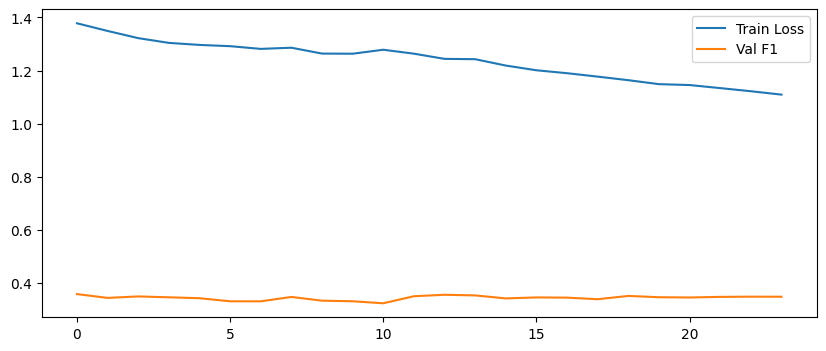

In [25]:
# 1. Initialize Model
num_classes = len(le.classes_)
model = build_model(CONFIG.MODEL_NAME, num_classes, CONFIG.DROPOUT)

# 2. Setup Tools
class_weights = class_weight.compute_class_weight(
    "balanced", classes=np.unique(y_train), y=y_train
)

class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
scaler = torch.cuda.amp.GradScaler()

# 3. STAGE 1: Train Head Only
print("\n🔥 STAGE 1: Training Head...")
set_parameter_requires_grad(model, feature_extracting=True)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CONFIG.LR_HEAD
)

trainer = Trainer(
    model, 
    criterion, 
    optimizer, 
    scaler, 
    device,
    monitor="val_loss", 
    mode="min",         
    min_delta=0.001
)

trainer.fit(
    train_loader, val_loader,
    epochs=CONFIG.EPOCHS_HEAD,
    patience=10,
    save_name="stage1_model"
)

# 4. STAGE 2: Fine-Tuning Backbone
print("\n🔥 STAGE 2: Fine Tuning Backbone...")
set_parameter_requires_grad(model, feature_extracting=False)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CONFIG.LR_FINE,
    weight_decay=1e-4
)

trainer.optimizer = optimizer

trainer.fit(
    train_loader,
    val_loader,
    epochs=CONFIG.EPOCHS_FINE,
    patience=CONFIG.PATIENCE,
    save_name="best_model"
)

# 5. Plot Results
plt.figure(figsize=(10,4))
plt.plot(trainer.history['train_loss'], label='Train Loss')
plt.plot(trainer.history['val_f1'], label='Val F1')
plt.legend()
plt.show()


## Tuning

In [29]:
import optuna

def objective(trial):
    # --- Hyperparameters to tune ---
    dropout = trial.suggest_float("dropout", 0.1, 0.6)
    lr_head = trial.suggest_loguniform("lr_head", 1e-5, 1e-3)
    lr_fine = trial.suggest_loguniform("lr_fine", 1e-6, 1e-4)
    weight_decay = trial.suggest_loguniform("weight_decay", 1e-6, 1e-3)
    
    # (Optional) tune architecture
    model_name = trial.suggest_categorical(
        "model_name", ["efficientnet", "resnet50", "phikon"]
    )

    # --- Build model with chosen params ---
    model = build_model(model_name, num_classes, dropout)

    # --- Stage 1: train head ---
    set_parameter_requires_grad(model, True)

    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr_head
    )

    trainer = Trainer(
        model=model,
        criterion=criterion,
        optimizer=optimizer,
        scaler=scaler,
        device=device,
        monitor="val_loss",
        mode="min"
    )

    trainer.fit(
        train_loader,
        val_loader,
        epochs=10,      # keep low for tuning
        patience=3,
        save_name=f"trial_{trial.number}_stage1"
    )

    # --- Stage 2: finetune backbone ---
    set_parameter_requires_grad(model, False)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr_fine,
        weight_decay=weight_decay
    )
    trainer.optimizer = optimizer

    trainer.fit(
        train_loader,
        val_loader,
        epochs=20,     # keep low for tuning
        patience=5,
        save_name=f"trial_{trial.number}_stage2"
    )

    # return metric to maximize/minimize
    return trainer.best_val_f1
study = optuna.create_study(
    direction="maximize",
    study_name="med_classifier_tuning"
)

study.optimize(objective, n_trials=10)  # start with 10 to test pipeline


[I 2025-12-08 00:15:03,730] A new study created in memory with name: med_classifier_tuning


🏗️ Building model: PHIKON
   Loading Owkin/Phikon (ViT-Base)...


config.json:   0%|          | 0.00/492 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of the model checkpoint at owkin/phikon were not used when initializing ViTModel: ['pooler.dense.bias', 'pooler.dense.weight']
- This IS expected if you are initializing ViTModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing ViTModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


...

[I 2025-12-08 01:07:15,188] Trial 8 finished with value: 0.3544936380470504 and parameters: {'dropout': 0.4792479199190127, 'lr_head': 0.00084235054788122, 'lr_fine': 7.713717382989867e-05, 'weight_decay': 0.00023988750150685163, 'model_name': 'efficientnet'}. Best is trial 5 with value: 0.42575497313636473.


🏗️ Building model: PHIKON
   Loading Owkin/Phikon (ViT-Base)...


Some weights of the model checkpoint at owkin/phikon were not used when initializing ViTModel: ['pooler.dense.bias', 'pooler.dense.weight']
- This IS expected if you are initializing ViTModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing ViTModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


✅ Model frozen. Only head (and norm) are trainable.
Epoch 1/10 | T_Loss: 1.3103 T_F1: 0.3532 | V_Loss: 1.2670 V_F1: 0.3672
Epoch 2/10 | T_Loss: 1.2269 T_F1: 0.4078 | V_Loss: 1.2567 V_F1: 0.3268
Epoch 3/10 | T_Loss: 1.1970 T_F1: 0.4219 | V_Loss: 1.3043 V_F1: 0.3012
Epoch 4/10 | T_Loss: 1.1714 T_F1: 0.4365 | V_Loss: 1.2851 V_F1: 0.3797
Epoch 5/10 | T_Loss: 1.1402 T_F1: 0.4741 | V_Loss: 1.3120 V_F1: 0.3768
🛑 Early stopping at epoch 5
Restoring best model (val_loss best = 1.2567)
✅ Model unfrozen. All layers are trainable.
Epoch 1/20 | T_Loss: 1.1796 T_F1: 0.4377 | V_Loss: 1.2685 V_F1: 0.3599
Epoch 2/20 | T_Loss: 1.0597 T_F1: 0.5055 | V_Loss: 1.3876 V_F1: 0.3125
Epoch 3/20 | T_Loss: 0.9279 T_F1: 0.5769 | V_Loss: 1.3932 V_F1: 0.3243
Epoch 4/20 | T_Loss: 0.7963 T_F1: 0.6411 | V_Loss: 1.4604 V_F1: 0.3415
Epoch 5/20 | T_Loss: 0.6879 T_F1: 0.6977 | V_Loss: 1.7097 V_F1: 0.3083
Epoch 6/20 | T_Loss: 0.5460 T_F1: 0.7670 | V_Loss: 2.0914 V_F1: 0.2844
🛑 Early stopping at epoch 6
Restoring best model 

[I 2025-12-08 01:13:46,141] Trial 9 finished with value: 0.37974977045985603 and parameters: {'dropout': 0.17101338660696744, 'lr_head': 0.0002729228976271603, 'lr_fine': 3.5240434035938526e-05, 'weight_decay': 4.6726025094569156e-05, 'model_name': 'phikon'}. Best is trial 5 with value: 0.42575497313636473.


In [32]:
# Load Optuna results
best_trial = study.best_trial
best_params = best_trial.params

print("🎉 Best Trial:", best_trial.number)
print("🏆 Best F1:", best_trial.value)
print("🔧 Best Params:", best_params)

# Extract parameters
best_model_name   = best_params["model_name"]
best_dropout      = best_params["dropout"]
best_lr_head      = best_params["lr_head"]
best_lr_fine      = best_params["lr_fine"]
best_weight_decay = best_params["weight_decay"]

# Build model with best architecture + dropout
model = build_model(best_model_name, num_classes, best_dropout)

# Load checkpoint from best trial
checkpoint_path = f"trial_{best_trial.number}_stage2.pt"
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.to(device)
model.eval()

print(f"\n✅ Loaded best model checkpoint: {checkpoint_path}")


🎉 Best Trial: 5
🏆 Best F1: 0.42575497313636473
🔧 Best Params: {'dropout': 0.596938450227561, 'lr_head': 7.236914823291574e-05, 'lr_fine': 1.1792056879109917e-05, 'weight_decay': 9.832837323725161e-05, 'model_name': 'phikon'}
🏗️ Building model: PHIKON
   Loading Owkin/Phikon (ViT-Base)...


Some weights of the model checkpoint at owkin/phikon were not used when initializing ViTModel: ['pooler.dense.bias', 'pooler.dense.weight']
- This IS expected if you are initializing ViTModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing ViTModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).



✅ Loaded best model checkpoint: trial_5_stage2.pt


## 💫 **Confusion Matrix**

In [33]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

def generate_confusion_matrix(model, loader, device, class_names):
    """
    Runs the model on the loader, generates predictions, and plots the matrix.
    """
    model.eval()
    all_preds = []
    all_labels = []
    
    print("📊 Generating Confusion Matrix...")
    
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(device)
            lbls = lbls.to(device)
            
            # Use AutoCast for consistent performance
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(imgs)
            
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(lbls.cpu().numpy())
            
    # Calculate Matrix
    cm = confusion_matrix(all_labels, all_preds)
    
    # Calculate Normalized Matrix (Recall per class)
    # epsilon added to prevent division by zero
    cm_norm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-10)
    
    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    # Raw Counts
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names, 
                ax=axes[0], square=True)
    axes[0].set_title('Confusion Matrix (Raw Counts)', fontweight='bold')
    axes[0].set_ylabel('True Label')
    axes[0].set_xlabel('Predicted Label')
    
    # Normalized
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens', 
                xticklabels=class_names, yticklabels=class_names, 
                ax=axes[1], square=True)
    axes[1].set_title('Confusion Matrix (Normalized %)', fontweight='bold')
    axes[1].set_ylabel('True Label')
    axes[1].set_xlabel('Predicted Label')
    
    plt.tight_layout()
    plt.show()
    
    return all_labels, all_preds


🧐 Evaluating Best Model on Validation Set...
📊 Generating Confusion Matrix...


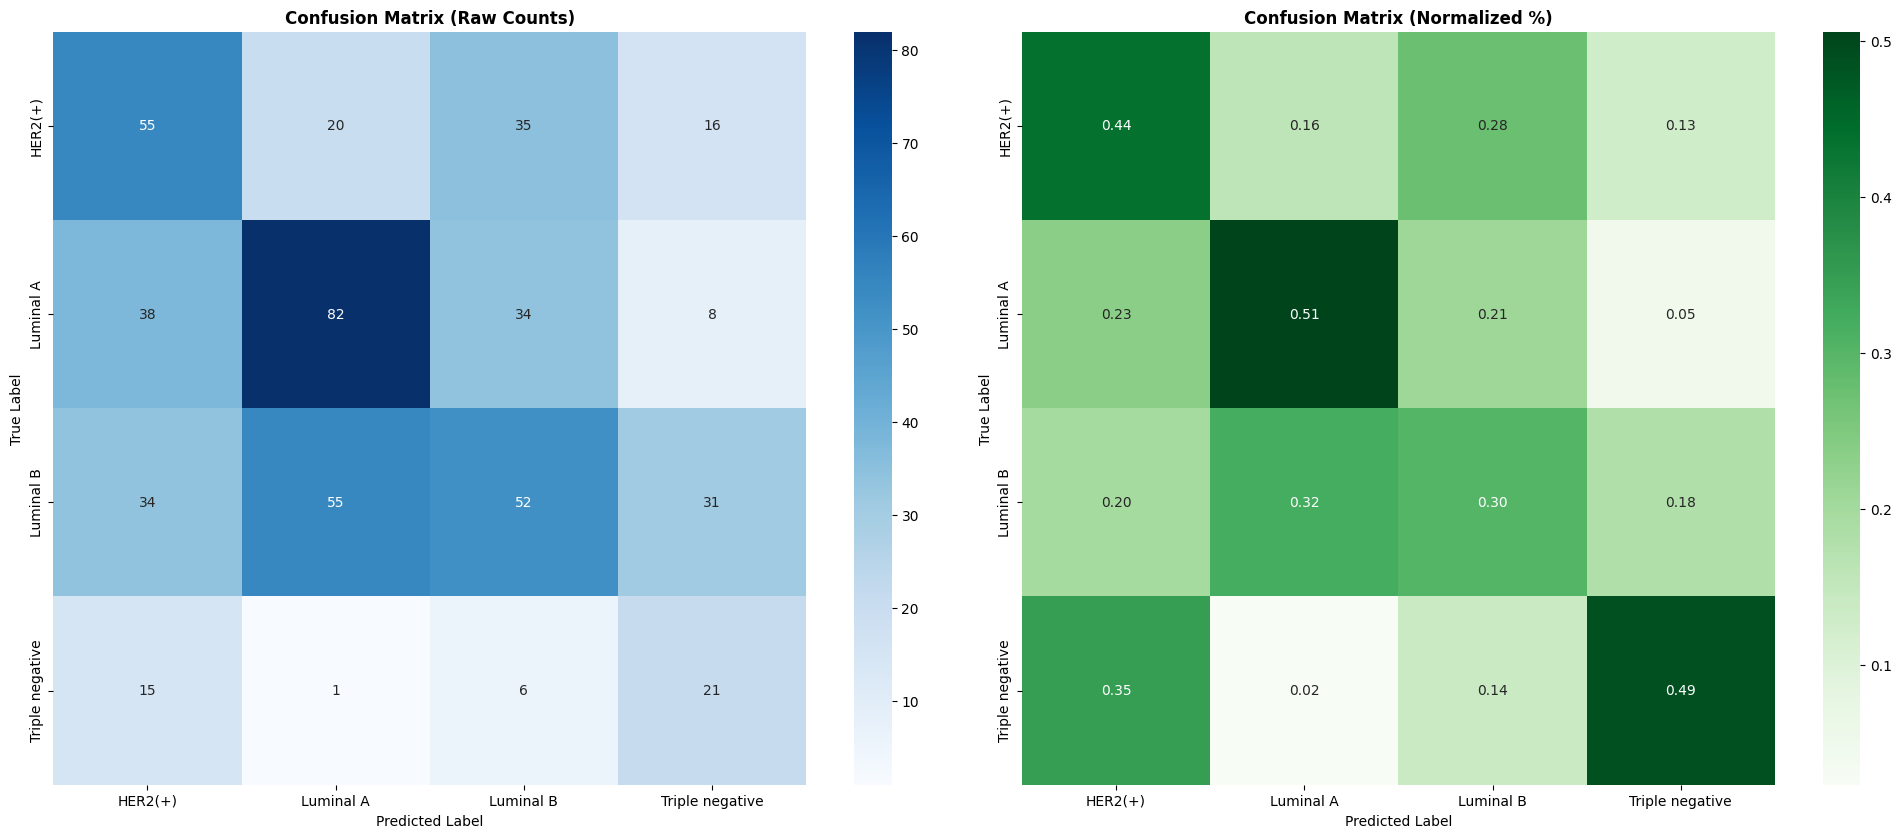


📑 Classification Report:
                 precision    recall  f1-score   support

        HER2(+)       0.39      0.44      0.41       126
      Luminal A       0.52      0.51      0.51       162
      Luminal B       0.41      0.30      0.35       172
Triple negative       0.28      0.49      0.35        43

       accuracy                           0.42       503
      macro avg       0.40      0.43      0.41       503
   weighted avg       0.43      0.42      0.42       503



In [34]:
print("\n🧐 Evaluating Best Model on Validation Set...")

# Run confusion matrix generator
true_labels, pred_labels = generate_confusion_matrix(
    model,
    val_loader,
    device,
    le.classes_
)

# Full metrics report
from sklearn.metrics import classification_report

print("\n📑 Classification Report:")
print(classification_report(true_labels, pred_labels, target_names=le.classes_))


## 🕹️ **Use the Model - Make Inference**

In [35]:
print("\n🔎 Processing Test Data...")

test_rois = []
test_image_ids = []

for fname in sorted(os.listdir(CONFIG.TEST_DIR)):

    if not fname.lower().endswith((".png", ".jpg", ".jpeg", ".tif", ".bmp")):
        continue

    if "mask_" in fname:
        continue

    img_path = os.path.join(CONFIG.TEST_DIR, fname)
    mask_path = img_path.replace("img_", "mask_")

    # Extract ROIs
    rois = extract_all_rois(
        img_path=img_path,
        mask_path=mask_path,
        label=None,
        img_name=fname,
        resize=True
    )

    # Fallback if no ROI
    if len(rois) == 0:
        print(f"⚠️ No ROI found for {fname}, using fallback center crop.")

        fallback = Image.open(img_path).convert("RGB")
        fallback = fallback.resize((224,224), Image.LANCZOS)
        fallback = np.array(fallback).astype(np.float32) / 255.0

        rois = [{"roi": fallback, "img_name": fname, "label": None}]

    for r in rois:
        test_rois.append(r["roi"])
        test_image_ids.append(fname)

# Build dataset
test_ds = MedicalDataset(
    images=np.stack(test_rois),
    labels=None,
    transform=val_tf
)

test_loader = DataLoader(test_ds, batch_size=CONFIG.BATCH_SIZE, shuffle=False)

print("\n🔮 Running Inference...")

model.eval()
all_probs = []

with torch.no_grad():
    for imgs in test_loader:
        imgs = imgs.to(device)
        with torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
            logits = model(imgs)
            probs = torch.softmax(logits, dim=1)
        all_probs.append(probs.cpu().numpy())

all_probs = np.vstack(all_probs)
from collections import defaultdict

image_to_probs = defaultdict(list)

for prob, img_id in zip(all_probs, test_image_ids):
    image_to_probs[img_id].append(prob)

final_preds = {}

for img_id, prob_list in image_to_probs.items():
    mean_prob = np.mean(prob_list, axis=0)
    final_preds[img_id] = np.argmax(mean_prob)

predicted_labels = {
    img_id: le.inverse_transform([cls_idx])[0]
    for img_id, cls_idx in final_preds.items()
}
submission = pd.DataFrame({
    "sample_index": list(predicted_labels.keys()),
    "label": list(predicted_labels.values())
})

submission.to_csv("submission.csv", index=False)
print("\n🏆 Submission saved successfully!")



🔎 Processing Test Data...
⚠️ No ROI found for img_0034.png, using fallback center crop.

🔮 Running Inference...

🏆 Submission saved successfully!


In [36]:
submission.to_csv("16submission.csv", index=False)
print("\n🏆 Submission saved successfully!")


🏆 Submission saved successfully!
